In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("RetailPulse - Day 1 EDA")
print("Environment ready")

RetailPulse - Day 1 EDA
Environment ready


In [3]:

file = "../data/raw/online_retail_II.xlsx"

df_2009 = pd.read_excel(
    file,
    sheet_name="Year 2009-2010"
)

df_2010 = pd.read_excel(
    file,
    sheet_name="Year 2010-2011"
)

df = pd.concat(
    [df_2009, df_2010],
    ignore_index=True
)

print("Dataset Shape:", df.shape)


FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/online_retail_II.xlsx'

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
file = "data/processed/retail_cleaned.csv"
df = pd.read_csv(file)

# Convert invoice date to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())


FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/retail_cleaned.csv'

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
file = r"E:\data\processed\retail_cleaned.csv"
df = pd.read_csv(file)

# Convert date column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Calculate total sales
df["Sales"] = df["Quantity"] * df["Price"]

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)
df.head()


In [4]:

from pathlib import Path
import pandas as pd

file = Path(r"E:\RetailPulse\data\raw\online_retail_II.xlsx")

print("File exists:", file.exists())

df_2009 = pd.read_excel(
    file,
    sheet_name="Year 2009-2010"
)

df_2010 = pd.read_excel(
    file,
    sheet_name="Year 2010-2011"
)

df = pd.concat([df_2009, df_2010], ignore_index=True)

print("Dataset Shape:", df.shape)


File exists: True
Dataset Shape: (1067371, 8)


In [5]:
# Day 1: Data Quality Check

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDataset Information:")
df.info()

Dataset Shape: (1067371, 8)

Column Names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Missing Values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Duplicate Rows:
34335

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str     

In [6]:

# Day 1: Data Cleaning

# Create a copy of original data
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove rows with missing product descriptions
df_clean = df_clean.dropna(subset=["Description"])

# Remove cancelled invoices
df_clean = df_clean[
    ~df_clean["Invoice"].astype(str).str.startswith("C")
]

# Remove negative or zero quantity
df_clean = df_clean[df_clean["Quantity"] > 0]

# Remove zero or negative prices
df_clean = df_clean[df_clean["Price"] > 0]

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

print("\nMissing Values After Cleaning:")
print(df_clean.isnull().sum())

print("\nDuplicate Rows After Cleaning:")
print(df_clean.duplicated().sum())


Original Shape: (1067371, 8)
Cleaned Shape: (1007913, 8)

Missing Values After Cleaning:
Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    228488
Country             0
dtype: int64

Duplicate Rows After Cleaning:
0


In [7]:

from pathlib import Path

# Create processed folder if it does not exist
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# Save cleaned dataset
output_file = output_dir / "retail_cleaned.csv"
df_clean.to_csv(output_file, index=False)

print("File saved successfully!")
print("File path:", output_file.resolve())
print("Final dataset shape:", df_clean.shape)


File saved successfully!
File path: E:\data\processed\retail_cleaned.csv
Final dataset shape: (1007913, 8)


In [2]:
from pathlib import Path

print("Current folder:", Path.cwd())
print("CSV file exists:", output_file.exists())
print("CSV file location:", output_file.resolve())

Current folder: e:\RetailPulse


NameError: name 'output_file' is not defined

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
file_path = r"E:\data\processed\retail_cleaned.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)
df.head()


C:\Users\DRT-Admin\AppData\Local\Temp\ipykernel_12532\2731958900.py:7: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Dataset Loaded Successfully
Dataset Shape: (1007913, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:

# Convert columns to numeric where needed
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Calculate total sales
df["Sales"] = df["Quantity"] * df["Price"]

print("Total Sales:", df["Sales"].sum())
print("Total Orders:", df["Invoice"].nunique())
print("Total Customers:", df["Customer ID"].nunique())
print("Total Products:", df["StockCode"].nunique())


Total Sales: 20476260.448
Total Orders: 40079
Total Customers: 5878
Total Products: 4917


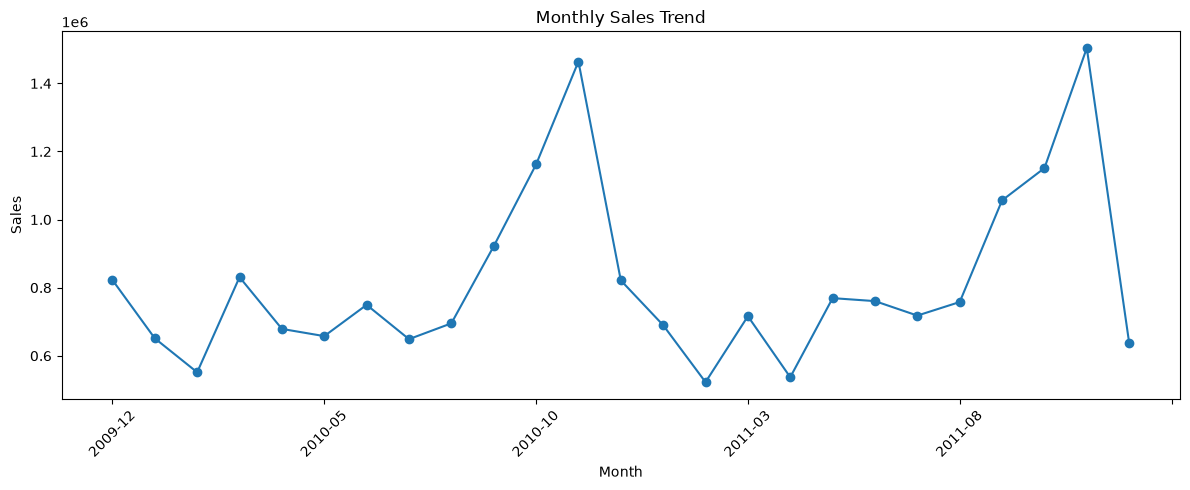

In [5]:

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"], errors="coerce"
)

monthly_sales = (
    df.dropna(subset=["InvoiceDate"])
      .groupby(df["InvoiceDate"].dt.to_period("M"))["Sales"]
      .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.plot(kind="line", marker="o", figsize=(12, 5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


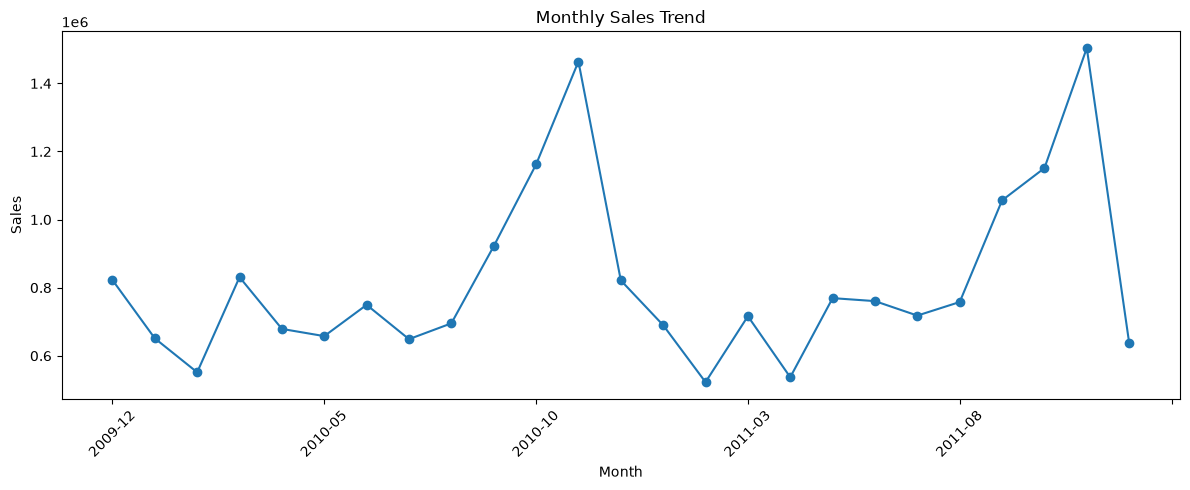

In [6]:

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"], errors="coerce"
)

monthly_sales = (
    df.dropna(subset=["InvoiceDate"])
      .groupby(df["InvoiceDate"].dt.to_period("M"))["Sales"]
      .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.plot(kind="line", marker="o", figsize=(12, 5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Top 10 Products by Revenue:


StockCode
M         339226.24
22423     330590.32
DOT       309854.11
85123A    257724.71
85099B    180569.34
23843     168469.60
47566     148318.28
84879     129324.49
POST      125682.42
22086     117760.29
Name: Sales, dtype: float64

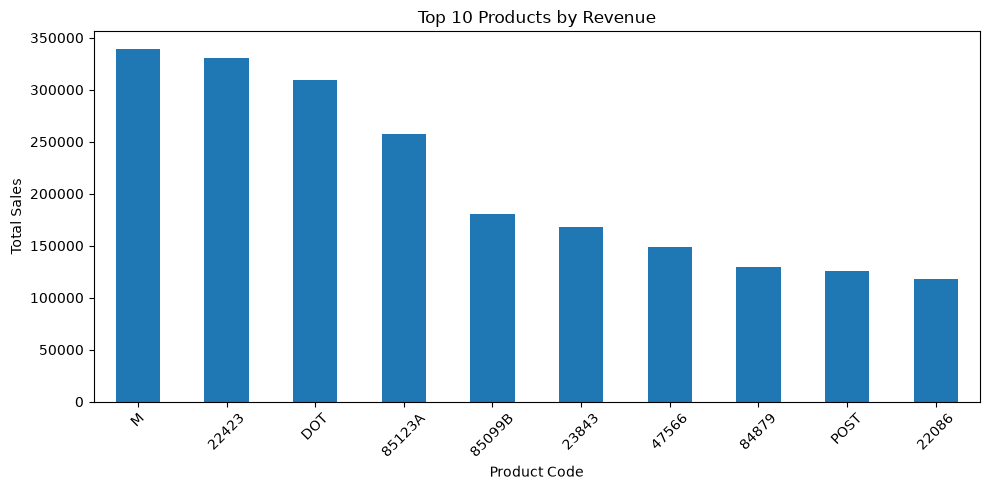

In [7]:

# Day 2: Top 10 Products by Revenue

df["Sales"] = df["Quantity"] * df["Price"]

top_products = (
    df[df["Quantity"] > 0]
    .groupby("StockCode")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Products by Revenue:")
display(top_products)

top_products.plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Code")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Top 10 Countries by Revenue:


Country
United Kingdom    1.741020e+07
EIRE              6.587673e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.504561e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.006856e+05
Sweden            9.186982e+04
Denmark           6.858069e+04
Name: Sales, dtype: float64

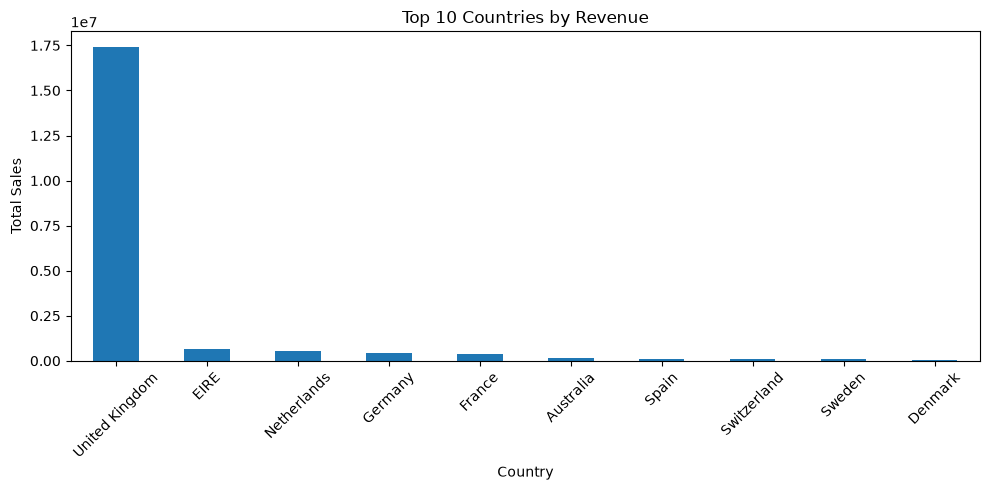

In [8]:

# Top 10 Countries by Revenue

country_sales = (
    df[df["Quantity"] > 0]
    .groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Countries by Revenue:")
display(country_sales)

country_sales.plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:

# Day 2: Business Insights Summary

total_revenue = df["Sales"].sum()

top_country = (
    df[df["Quantity"] > 0]
    .groupby("Country")["Sales"]
    .sum()
    .idxmax()
)

top_product = (
    df[df["Quantity"] > 0]
    .groupby("StockCode")["Sales"]
    .sum()
    .idxmax()
)

monthly = (
    df.dropna(subset=["InvoiceDate"])
    .groupby(df["InvoiceDate"].dt.to_period("M"))["Sales"]
    .sum()
)

print("===== RETAILPULSE BUSINESS INSIGHTS =====")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Top Country: {top_country}")
print(f"Top Product Code: {top_product}")
print(f"Best Sales Month: {monthly.idxmax()}")
print(f"Best Month Revenue: {monthly.max():,.2f}")


===== RETAILPULSE BUSINESS INSIGHTS =====
Total Revenue: 20,476,260.45
Top Country: United Kingdom
Top Product Code: M
Best Sales Month: 2011-11
Best Month Revenue: 1,503,866.78
